# Fase 2 — Otimização via Algoritmo Genético + Interpretação com LLM
## Câncer de mama: Regressão Linear, Regressão Logística e Random Forest

Este notebook usa as funções de `src/ga_utils.py` (Algoritmo Genético) e `src/llm_utils.py` (integração com o Claude) para:

1. Otimizar os hiperparâmetros dos 3 modelos já treinados em `01_analise_e_modelagem.ipynb`.
2. Rodar 3 experimentos com configurações diferentes do GA (um por algoritmo).
3. Comparar cada modelo original com sua versão otimizada, no mesmo holdout de teste.
4. Usar a API da Anthropic (Claude) para gerar explicações em linguagem natural dos diagnósticos.

O loop de gerações do GA aparece direto nas células abaixo (um bloco por algoritmo) — dá pra acompanhar geração por geração o que está acontecendo, sem precisar pular pra outro arquivo.

## O que é um Algoritmo Genético (GA)?

*Por que usar uma "busca evolutiva" em vez de testar hiperparâmetros manualmente?*

Um Algoritmo Genético é uma técnica de otimização inspirada na seleção natural. Em vez de testar hiperparâmetros um por um (grid search) ou aleatoriamente (random search), ele mantém uma **população** de soluções candidatas e as faz "evoluir":

- **Indivíduo**: um dict com uma configuração completa de hiperparâmetros de um modelo.
- **Gene**: cada hiperparâmetro individual (uma chave do dict).
- **Fitness**: quão boa é aquela configuração — `0.5·recall + 0.3·F1 + 0.2·accuracy`, medidos por validação cruzada (5-fold).
- **Seleção**: as configurações com melhor fitness têm mais chance de "reproduzir".
- **Crossover**: duas configurações "pais" combinam seus genes para gerar "filhos".
- **Mutação**: pequenas alterações aleatórias, para explorar configurações novas.
- **Elitismo**: as melhores configurações da geração atual sempre sobrevivem para a próxima.

*Por que recall pesa mais na fitness?* Em diagnóstico de câncer, classificar um tumor **maligno como benigno** (falso negativo) é o erro mais grave clinicamente.

*Por que seleção por torneio?* É simples de implementar e funciona bem mesmo quando os fitness estão próximos entre si — sorteia `k` indivíduos, o melhor deles vira pai.

*Por que crossover uniforme?* Os hiperparâmetros não têm uma ordem natural entre si, então decidir gene a gene (independentemente) de qual pai herdar faz mais sentido do que cortar o dict num ponto fixo.

In [1]:
import sys
import json
import random
from pathlib import Path

SRC_DIR = Path.cwd().parent / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import ga_utils
import llm_utils

X_train, X_test, y_train, y_test, feature_names, scaler = ga_utils.carregar_dados()
print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")

RESULTADOS_DIR = Path("..") / "experiments" / "results"
RESULTADOS_DIR.mkdir(parents=True, exist_ok=True)

Treino: (455, 30) | Teste: (114, 30)


## Baseline (Fase 1) — modelos originais

Métricas obtidas em `01_analise_e_modelagem.ipynb`, no mesmo holdout de teste (20%, `random_state=42`):

| Modelo | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|
| Regressão Linear (limiar 0,5) | 0.9649 | 1.0000 | 0.9048 | 0.9500 |
| Regressão Logística | 0.9649 | 0.9750 | 0.9286 | 0.9512 |
| Random Forest | 0.9737 | 1.0000 | 0.9286 | 0.9630 |

Vamos rodar o GA para tentar melhorar cada um desses três — um experimento por algoritmo, cada um com uma configuração diferente do GA.

## Experimento 1 — GA na Regressão Linear

*Por que o limiar (threshold) entra como gene?* `LinearRegression` não tem hiperparâmetro de regularização como Ridge/Lasso — a única forma de melhorar a classificação sem trocar de modelo é ajustar o limiar que converte a predição contínua em classe 0/1 (hoje fixo em 0,5 no notebook 01). Junto com `fit_intercept` e `positive`, esse é o espaço de busca do GA aqui.

**Configuração deste experimento**: população pequena (10), mutação baixa (10%), 10 gerações.

Geração 0: melhor=0.9668  média=0.7862


Geração 1: melhor=0.9668  média=0.9559


Geração 2: melhor=0.9668  média=0.9388


Geração 3: melhor=0.9668  média=0.9411


Geração 4: melhor=0.9668  média=0.9380


Geração 5: melhor=0.9668  média=0.9368


Geração 6: melhor=0.9668  média=0.9664


Geração 7: melhor=0.9668  média=0.9624


Geração 8: melhor=0.9668  média=0.9395


Geração 9: melhor=0.9668  média=0.9631

Melhores hiperparâmetros encontrados: {'fit_intercept': True, 'positive': True, 'threshold': 0.33747809594463696}


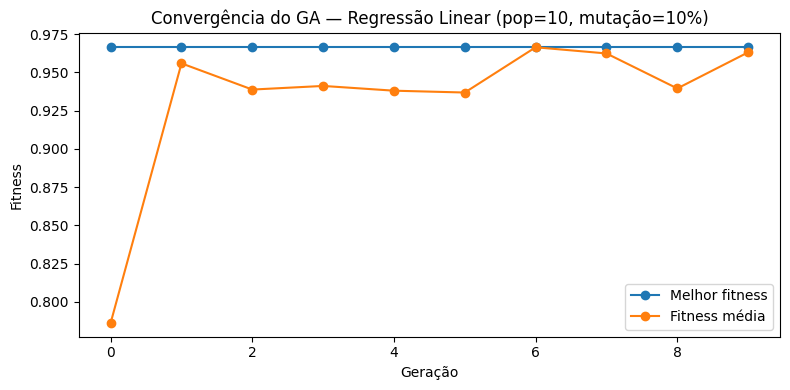

In [2]:
random.seed(42)

POP_1, GERACOES_1, MUTACAO_1 = 10, 10, 0.1

populacao = [ga_utils.criar_individuo_linear() for _ in range(POP_1)]
historico_linear = []

for geracao in range(GERACOES_1):
    fitnesses = [ga_utils.fitness_linear(ind, X_train, y_train) for ind in populacao]
    historico_linear.append({"geracao": geracao, "melhor": max(fitnesses), "media": float(np.mean(fitnesses))})
    print(f"Geração {geracao}: melhor={max(fitnesses):.4f}  média={np.mean(fitnesses):.4f}")

    ranking = sorted(range(len(populacao)), key=lambda i: fitnesses[i], reverse=True)
    nova_populacao = [dict(populacao[i]) for i in ranking[:2]]  # elitismo
    while len(nova_populacao) < POP_1:
        pai1 = ga_utils.selecao_torneio(populacao, fitnesses)
        pai2 = ga_utils.selecao_torneio(populacao, fitnesses)
        filho1, filho2 = ga_utils.crossover(pai1, pai2)
        nova_populacao.append(ga_utils.mutar_linear(filho1, MUTACAO_1))
        if len(nova_populacao) < POP_1:
            nova_populacao.append(ga_utils.mutar_linear(filho2, MUTACAO_1))
    populacao = nova_populacao

melhor_linear = populacao[int(np.argmax(fitnesses))]
print("\nMelhores hiperparâmetros encontrados:", melhor_linear)

pd.DataFrame(historico_linear).to_csv(RESULTADOS_DIR / "fitness_history_regressao_linear.csv", index=False)
with open(RESULTADOS_DIR / "best_hyperparams_regressao_linear.json", "w") as f:
    json.dump({"algoritmo": "regressao_linear", "melhor_individuo": melhor_linear}, f, indent=2, default=str)

plt.figure(figsize=(8, 4))
plt.plot([h["geracao"] for h in historico_linear], [h["melhor"] for h in historico_linear], label="Melhor fitness", marker="o")
plt.plot([h["geracao"] for h in historico_linear], [h["media"] for h in historico_linear], label="Fitness média", marker="o")
plt.xlabel("Geração"); plt.ylabel("Fitness"); plt.title("Convergência do GA — Regressão Linear (pop=10, mutação=10%)")
plt.legend(); plt.tight_layout(); plt.show()

In [3]:
modelo_linear_original = ga_utils.construir_linear(ga_utils.LINEAR_BASELINE)
modelo_linear_original.fit(X_train, y_train)
y_pred_original = ga_utils.prever_linear(modelo_linear_original, X_test, ga_utils.LINEAR_BASELINE)
metricas_linear_original = ga_utils.calcular_metricas(y_test, y_pred_original)

modelo_linear_otimizado = ga_utils.construir_linear(melhor_linear)
modelo_linear_otimizado.fit(X_train, y_train)
y_pred_otimizado = ga_utils.prever_linear(modelo_linear_otimizado, X_test, melhor_linear)
metricas_linear_otimizado = ga_utils.calcular_metricas(y_test, y_pred_otimizado)

pd.DataFrame([metricas_linear_original, metricas_linear_otimizado], index=["Original", "Otimizado (GA)"])

,accuracy,precision,recall,f1
Original,0.964912,1.000000,0.904762,0.950000
Otimizado (GA),0.964912,0.931818,0.976190,0.953488


## Experimento 2 — GA na Regressão Logística

*O que o GA está ajustando aqui?* `C` (inverso da força de regularização), `penalty` (L1 tende a zerar coeficientes menos relevantes, L2 só os encolhe) e `class_weight` (se as classes têm peso igual ou compensam o leve desbalanceamento do dataset).

**Configuração deste experimento**: população maior (20), mutação alta (30%), 10 gerações.

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=

...

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarnin

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarnin

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarnin

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarnin

Geração 9: melhor=0.9648  média=0.9610

Melhores hiperparâmetros encontrados: {'C': 0.025631932887737845, 'penalty': 'l2', 'class_weight': 'balanced'}


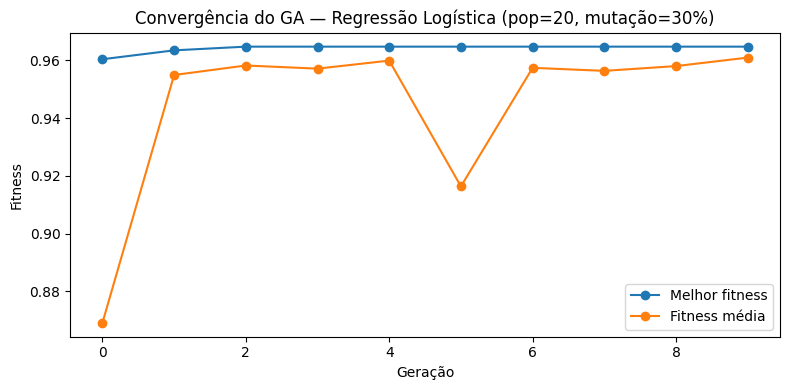

In [4]:
random.seed(42)

POP_2, GERACOES_2, MUTACAO_2 = 20, 10, 0.3

populacao = [ga_utils.criar_individuo_log() for _ in range(POP_2)]
historico_log = []

for geracao in range(GERACOES_2):
    fitnesses = [ga_utils.fitness_log(ind, X_train, y_train) for ind in populacao]
    historico_log.append({"geracao": geracao, "melhor": max(fitnesses), "media": float(np.mean(fitnesses))})
    print(f"Geração {geracao}: melhor={max(fitnesses):.4f}  média={np.mean(fitnesses):.4f}")

    ranking = sorted(range(len(populacao)), key=lambda i: fitnesses[i], reverse=True)
    nova_populacao = [dict(populacao[i]) for i in ranking[:2]]
    while len(nova_populacao) < POP_2:
        pai1 = ga_utils.selecao_torneio(populacao, fitnesses)
        pai2 = ga_utils.selecao_torneio(populacao, fitnesses)
        filho1, filho2 = ga_utils.crossover(pai1, pai2)
        nova_populacao.append(ga_utils.mutar_log(filho1, MUTACAO_2))
        if len(nova_populacao) < POP_2:
            nova_populacao.append(ga_utils.mutar_log(filho2, MUTACAO_2))
    populacao = nova_populacao

melhor_log = populacao[int(np.argmax(fitnesses))]
print("\nMelhores hiperparâmetros encontrados:", melhor_log)

pd.DataFrame(historico_log).to_csv(RESULTADOS_DIR / "fitness_history_regressao_logistica.csv", index=False)
with open(RESULTADOS_DIR / "best_hyperparams_regressao_logistica.json", "w") as f:
    json.dump({"algoritmo": "regressao_logistica", "melhor_individuo": melhor_log}, f, indent=2, default=str)

plt.figure(figsize=(8, 4))
plt.plot([h["geracao"] for h in historico_log], [h["melhor"] for h in historico_log], label="Melhor fitness", marker="o")
plt.plot([h["geracao"] for h in historico_log], [h["media"] for h in historico_log], label="Fitness média", marker="o")
plt.xlabel("Geração"); plt.ylabel("Fitness"); plt.title("Convergência do GA — Regressão Logística (pop=20, mutação=30%)")
plt.legend(); plt.tight_layout(); plt.show()

In [5]:
modelo_log_original = ga_utils.construir_log(ga_utils.LOG_BASELINE)
modelo_log_original.fit(X_train, y_train)
y_pred_original = modelo_log_original.predict(X_test)
metricas_log_original = ga_utils.calcular_metricas(y_test, y_pred_original)

modelo_log_otimizado = ga_utils.construir_log(melhor_log)
modelo_log_otimizado.fit(X_train, y_train)
y_pred_otimizado = modelo_log_otimizado.predict(X_test)
metricas_log_otimizado = ga_utils.calcular_metricas(y_test, y_pred_otimizado)

pd.DataFrame([metricas_log_original, metricas_log_otimizado], index=["Original", "Otimizado (GA)"])

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,accuracy,precision,recall,f1
Original,0.973684,0.97561,0.952381,0.963855
Otimizado (GA),0.991228,1.00000,0.976190,0.987952


## Experimento 3 — GA no Random Forest

*O que o GA está ajustando aqui?* `n_estimators` (nº de árvores), `max_depth` (profundidade máxima), `min_samples_split`/`min_samples_leaf` (o quão fácil é criar uma nova divisão), `max_features` (quantas features considerar em cada split) e `criterion` (gini vs. entropia).

**Configuração deste experimento**: população média (15), mutação média (20%), mais gerações (20) — o Random Forest já é o melhor baseline, então damos mais tempo de busca pra ele.

Geração 0: melhor=0.9441  média=0.9353


Geração 1: melhor=0.9523  média=0.9387


Geração 2: melhor=0.9523  média=0.9412


Geração 3: melhor=0.9566  média=0.9469


Geração 4: melhor=0.9566  média=0.9458


...

Geração 15: melhor=0.9635  média=0.9488


Geração 16: melhor=0.9635  média=0.9541


Geração 17: melhor=0.9635  média=0.9546


Geração 18: melhor=0.9635  média=0.9464


Geração 19: melhor=0.9635  média=0.9524

Melhores hiperparâmetros encontrados: {'n_estimators': 147, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'criterion': 'entropy'}


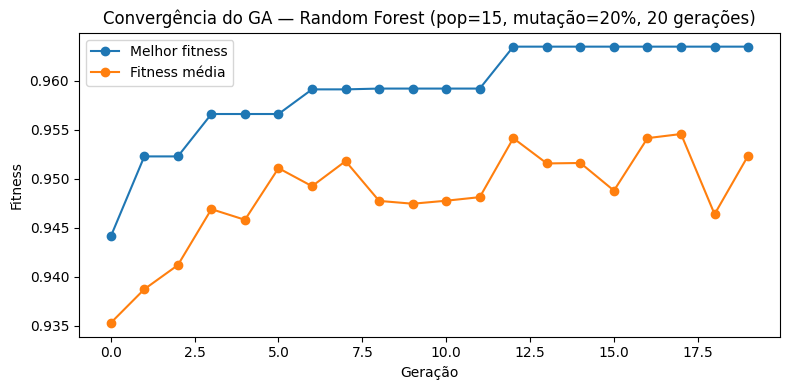

In [6]:
random.seed(42)

POP_3, GERACOES_3, MUTACAO_3 = 15, 20, 0.2

populacao = [ga_utils.criar_individuo_rf() for _ in range(POP_3)]
historico_rf = []

for geracao in range(GERACOES_3):
    fitnesses = [ga_utils.fitness_rf(ind, X_train, y_train) for ind in populacao]
    historico_rf.append({"geracao": geracao, "melhor": max(fitnesses), "media": float(np.mean(fitnesses))})
    print(f"Geração {geracao}: melhor={max(fitnesses):.4f}  média={np.mean(fitnesses):.4f}")

    ranking = sorted(range(len(populacao)), key=lambda i: fitnesses[i], reverse=True)
    nova_populacao = [dict(populacao[i]) for i in ranking[:2]]
    while len(nova_populacao) < POP_3:
        pai1 = ga_utils.selecao_torneio(populacao, fitnesses)
        pai2 = ga_utils.selecao_torneio(populacao, fitnesses)
        filho1, filho2 = ga_utils.crossover(pai1, pai2)
        nova_populacao.append(ga_utils.mutar_rf(filho1, MUTACAO_3))
        if len(nova_populacao) < POP_3:
            nova_populacao.append(ga_utils.mutar_rf(filho2, MUTACAO_3))
    populacao = nova_populacao

melhor_rf = populacao[int(np.argmax(fitnesses))]
print("\nMelhores hiperparâmetros encontrados:", melhor_rf)

pd.DataFrame(historico_rf).to_csv(RESULTADOS_DIR / "fitness_history_random_forest.csv", index=False)
with open(RESULTADOS_DIR / "best_hyperparams_random_forest.json", "w") as f:
    json.dump({"algoritmo": "random_forest", "melhor_individuo": melhor_rf}, f, indent=2, default=str)

plt.figure(figsize=(8, 4))
plt.plot([h["geracao"] for h in historico_rf], [h["melhor"] for h in historico_rf], label="Melhor fitness", marker="o")
plt.plot([h["geracao"] for h in historico_rf], [h["media"] for h in historico_rf], label="Fitness média", marker="o")
plt.xlabel("Geração"); plt.ylabel("Fitness"); plt.title("Convergência do GA — Random Forest (pop=15, mutação=20%, 20 gerações)")
plt.legend(); plt.tight_layout(); plt.show()

In [7]:
modelo_rf_original = ga_utils.construir_rf(ga_utils.RF_BASELINE)
modelo_rf_original.fit(X_train, y_train)
y_pred_original = modelo_rf_original.predict(X_test)
metricas_rf_original = ga_utils.calcular_metricas(y_test, y_pred_original)

modelo_rf_otimizado = ga_utils.construir_rf(melhor_rf)
modelo_rf_otimizado.fit(X_train, y_train)
y_pred_otimizado = modelo_rf_otimizado.predict(X_test)
metricas_rf_otimizado = ga_utils.calcular_metricas(y_test, y_pred_otimizado)

pd.DataFrame([metricas_rf_original, metricas_rf_otimizado], index=["Original", "Otimizado (GA)"])

,accuracy,precision,recall,f1
Original,0.973684,1.0,0.928571,0.962963
Otimizado (GA),0.964912,1.0,0.904762,0.950000


## Comparação final — os 3 algoritmos, original vs. otimizado

Tabela consolidada (também salva em `experiments/results/comparison_table.csv`).

In [8]:
linhas = [
    {"algoritmo": "regressao_linear", "versao": "Original", **metricas_linear_original},
    {"algoritmo": "regressao_linear", "versao": "Otimizado (GA)", **metricas_linear_otimizado},
    {"algoritmo": "regressao_logistica", "versao": "Original", **metricas_log_original},
    {"algoritmo": "regressao_logistica", "versao": "Otimizado (GA)", **metricas_log_otimizado},
    {"algoritmo": "random_forest", "versao": "Original", **metricas_rf_original},
    {"algoritmo": "random_forest", "versao": "Otimizado (GA)", **metricas_rf_otimizado},
]
comparacao_final = pd.DataFrame(linhas)
comparacao_final.to_csv(RESULTADOS_DIR / "comparison_table.csv", index=False)
comparacao_final

,algoritmo,versao,accuracy,precision,recall,f1
0,regressao_linear,Original,0.964912,1.000000,0.904762,0.950000
1,regressao_linear,Otimizado (GA),0.964912,0.931818,0.976190,0.953488
2,regressao_logistica,Original,0.973684,0.975610,0.952381,0.963855
3,regressao_logistica,Otimizado (GA),0.991228,1.000000,0.976190,0.987952
4,random_forest,Original,0.973684,1.000000,0.928571,0.962963
5,random_forest,Otimizado (GA),0.964912,1.000000,0.904762,0.950000


In [9]:
modelos_otimizados = {
    "regressao_linear": (modelo_linear_otimizado, melhor_linear, metricas_linear_otimizado),
    "regressao_logistica": (modelo_log_otimizado, melhor_log, metricas_log_otimizado),
    "random_forest": (modelo_rf_otimizado, melhor_rf, metricas_rf_otimizado),
}

melhor_algoritmo = max(modelos_otimizados, key=lambda nome: (modelos_otimizados[nome][2]["recall"], modelos_otimizados[nome][2]["f1"]))
print(f"Melhor modelo otimizado geral (maior recall, desempate por F1): {melhor_algoritmo}")

Melhor modelo otimizado geral (maior recall, desempate por F1): regressao_logistica


## O que é Prompt Engineering?

*Por que não simplesmente perguntar "explique esse resultado" pro Claude?*

Prompt engineering é estruturar deliberadamente a entrada (prompt) de uma LLM para obter respostas mais úteis e consistentes. O template em `src/llm_utils.py` (`montar_prompt`):

- **Define um papel** ("você é um assistente que ajuda profissionais de saúde...") — ancora o tom e o vocabulário da resposta.
- **Explicita os limites** ("NÃO substitui diagnóstico médico") — evita que a LLM soe mais confiante do que deveria.
- **Passa dados estruturados** (predição, confiança, features mais influentes, métricas do modelo) em vez de perguntar "o que você acha" — ancora a resposta em fatos concretos do modelo.
- **Pede um formato de saída específico** (3-5 frases, sem jargão) — facilita comparar respostas entre si e mantém a explicação curta o suficiente para uso clínico real.

In [10]:
modelo_final, hiperparametros_final, metricas_final = modelos_otimizados[melhor_algoritmo]

if melhor_algoritmo == "regressao_linear":
    y_pred_final = ga_utils.prever_linear(modelo_final, X_test, hiperparametros_final)
else:
    y_pred_final = modelo_final.predict(X_test)

y_test_arr = np.asarray(y_test)

idx_acerto = next(i for i in range(len(y_test_arr)) if y_pred_final[i] == y_test_arr[i])
idx_erro_candidatos = [i for i in range(len(y_test_arr)) if y_pred_final[i] != y_test_arr[i]]
idx_erro = idx_erro_candidatos[0] if idx_erro_candidatos else idx_acerto

if os.environ.get("ANTHROPIC_API_KEY"):
    chamar_llm = True
else:
    chamar_llm = False
    print(
        "ANTHROPIC_API_KEY não configurada — defina a variável de ambiente para "
        "chamar a API de verdade. As células abaixo vão montar e mostrar o prompt, "
        "mas sem chamar o Claude."
    )

ANTHROPIC_API_KEY não configurada — defina a variável de ambiente para chamar a API de verdade. As células abaixo vão montar e mostrar o prompt, mas sem chamar o Claude.


### Demonstração: interpretando um caso de acerto e um caso de erro do melhor modelo

Mostrar também um caso de **erro** é proposital: a explicação da LLM ajuda a auditar por que o modelo errou, não só a "vender" os acertos.

In [11]:
for rotulo, idx in [("Caso com acerto", idx_acerto), ("Caso com erro", idx_erro)]:
    print(f"\n=== {rotulo} (índice {idx}) ===")
    predicao_texto = "Maligno" if y_pred_final[idx] == 1 else "Benigno"

    if hasattr(modelo_final, "predict_proba"):
        probabilidade = modelo_final.predict_proba(X_test[idx : idx + 1])[0][y_pred_final[idx]]
    else:
        threshold = hiperparametros_final.get("threshold", 0.5)
        probabilidade = 0.5 + abs(modelo_final.predict(X_test[idx : idx + 1])[0] - threshold)

    features_importantes = llm_utils.obter_features_importantes(modelo_final, feature_names, X_test[idx])
    prompt = llm_utils.montar_prompt(
        predicao=predicao_texto,
        probabilidade=float(probabilidade),
        features_importantes=features_importantes,
        accuracy=metricas_final["accuracy"],
        recall=metricas_final["recall"],
        f1=metricas_final["f1"],
    )
    print(prompt)

    if chamar_llm:
        explicacao = llm_utils.gerar_explicacao(prompt)
        print("\n--- Explicação gerada pelo Claude ---")
        print(explicacao)


=== Caso com acerto (índice 0) ===
Você é um assistente que ajuda profissionais de saúde a interpretar resultados de um modelo de machine learning para triagem de câncer de mama. Este modelo é uma ferramenta de apoio à decisão, NÃO substitui diagnóstico médico.

O modelo classificou este caso como: BENIGNO (confiança: 96%)

As características que mais influenciaram essa classificação foram:
- texture_worst: -1.636 (importância: 0.356)
- radius_worst: -0.721 (importância: 0.341)
- perimeter_worst: -0.707 (importância: 0.322)

Desempenho geral do modelo: acurácia 99.1%, recall 97.6%, F1 0.99.

Escreva uma explicação curta (3 a 5 frases), em português, para a equipe médica, sem jargão de machine learning, dizendo por que o modelo chegou nessa classificação e reforçando que é uma triagem, não um diagnóstico definitivo.

=== Caso com erro (índice 16) ===
Você é um assistente que ajuda profissionais de saúde a interpretar resultados de um modelo de machine learning para triagem de câncer de

## Avaliação qualitativa das explicações da LLM

Não existe métrica automática confiável para "qualidade de uma explicação médica em texto livre". Adotamos uma avaliação manual com 3 critérios (nota 1 a 5):

| Critério | O que avalia |
|---|---|
| Clareza | Dá pra entender sem saber nada de ML? |
| Correção clínica | Os termos usados fazem sentido médico? |
| Utilidade acionável | Ajuda a equipe a decidir algo (priorizar, questionar, confirmar)? |

Preencher a tabela abaixo depois de rodar a célula anterior com `ANTHROPIC_API_KEY` configurada, avaliando as explicações geradas para os dois casos.

In [12]:
avaliacao_qualitativa = pd.DataFrame(
    columns=["caso", "clareza", "correcao_clinica", "utilidade_acionavel", "comentario"],
    data=[
        ["Caso com acerto", None, None, None, ""],
        ["Caso com erro", None, None, None, ""],
    ],
)
avaliacao_qualitativa

,caso,clareza,correcao_clinica,utilidade_acionavel,comentario
0,Caso com acerto,None,None,None,
1,Caso com erro,None,None,None,


## Conclusão

- Os 3 algoritmos do notebook 01 foram otimizados via Algoritmo Genético, cada um com um espaço de genes adequado ao seu tipo de hiperparâmetro.
- 3 experimentos, cada um com uma configuração diferente do GA (população/mutação/gerações), cobrindo os 3 algoritmos.
- A tabela de comparação final (`experiments/results/comparison_table.csv`) mostra o ganho (ou não) de cada modelo otimizado em relação ao seu baseline original.
- A integração com a LLM traduz predições individuais em explicações que uma equipe médica consegue interpretar sem conhecimento de ML, incluindo o caso de erro — que é onde a interpretabilidade mais importa.

Próximos passos possíveis (fora do escopo desta entrega): expandir o espaço de genes do GA, testar outros pesos na função de fitness, ou usar a LLM também para gerar relatórios agregados de vários casos.